In [ ]:
import requests
import pandas as pd

print("Loading")


API_KEY = 'e81cb050c1544189a196255e0f5973c3'
SEARCH_TOPIC = 'Artificial Intelligence' 


url = f"https://newsapi.org/v2/everything?q={SEARCH_TOPIC}&language=en&sortBy=publishedAt&apiKey={API_KEY}"

response = requests.get(url)

if response.status_code == 200:
    articles = response.json().get('articles', [])
    print(f"✅ Successfully extracted {len(articles)} recent articles about '{SEARCH_TOPIC}'.")
    
    # convert JSON into DataFrame
    news_data = []
    for art in articles:
        # filter articles with title and description
        if art.get('title') and art.get('description'):
            news_data.append({
                'Source': art['source']['name'],
                'Published Date': art['publishedAt'],
                'Title': art['title'],
                'Description': art['description']
            })
            
    df_news = pd.DataFrame(news_data)
    
    # Clean datetime 
    df_news['Published Date'] = pd.to_datetime(df_news['Published Date']).dt.strftime('%Y-%m-%d %H:%M')
    
    print("\nHere is a preview of the unstructured text data:")
    print(df_news[['Source', 'Title']].head())
    
else:
    print(f"❌ Error: {response.status_code}")
    print(response.json())

Initializing News Extraction Pipeline...
✅ Successfully extracted 98 recent articles about 'Artificial Intelligence'.

Here is a preview of the unstructured text data:
                  Source                                              Title
0        Onefootball.com   Spain name World Cup squad with no players fr...
1          GlobeNewswire  Kane & Corso Breaks Silence: Top-Tier Fintech ...
2                Variety  Pope Leo Issues AI Manifesto Warning That ‘Opa...
3          GlobeNewswire  AI in Animal Health Market Size is Expected to...
4  Bitcoinfoundation.org  Experts Warn: AI Is Accelerating the Quantum T...


In [5]:
import requests
import pandas as pd
from datetime import datetime, timedelta

print("Loading")

# setup
API_KEY = 'e81cb050c1544189a196255e0f5973c3'
SEARCH_TOPIC = '("oil prices" OR "crude oil") AND (conflict OR spike OR crisis OR surge)'

# Date Range 
today = datetime.now()
thirty_days_ago = today - timedelta(days=30)

# Format dates 
date_from = thirty_days_ago.strftime('%Y-%m-%d')
date_to = today.strftime('%Y-%m-%d')

print(f"Scanning news from {date_from} to {date_to}...")


url = f"https://newsapi.org/v2/everything?q={SEARCH_TOPIC}&from={date_from}&to={date_to}&language=en&sortBy=relevancy&apiKey={API_KEY}"

response = requests.get(url)

if response.status_code == 200:
    articles = response.json().get('articles', [])
    print(f"✅ Successfully extracted {len(articles)} articles!")
    
    # 4. Convert to DataFrame
    news_data = []
    for art in articles:
        if art.get('title') and art.get('description'):
            news_data.append({
                'Source': art['source']['name'],
                'Published Date': art['publishedAt'],
                'Title': art['title'],
                'Description': art['description']
            })
            
    df_news = pd.DataFrame(news_data)
    
    if not df_news.empty:
        df_news['Published Date'] = pd.to_datetime(df_news['Published Date']).dt.strftime('%Y-%m-%d')
        print("\nData Preview:")
        print(df_news[['Source', 'Title']].head())
    else:
        print("No valid articles found with descriptions.")
    
else:
    print(f"❌ Error: {response.status_code}")
    print(response.json())

Loading
Scanning news from 2026-04-26 to 2026-05-26...
✅ Successfully extracted 100 articles!

Data Preview:
             Source                                              Title
0          BBC News  Oil price jumps to $115 after reports of 'exte...
1  Business Insider  Wall Street's 'Dr. Doom' economist lays out 4 ...
2       Gizmodo.com  Oil Prices Surge After Iran Hits UAE Oil Facil...
3      The Next Web  Europe’s EV sales are surging as the Iran war ...
4  Business Insider  US gas prices surge to over $4.22 a gallon, th...


In [6]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

nltk.download('vader_lexicon')

print("\nLoading...")

sia = SentimentIntensityAnalyzer()

# scoring function
def analyze_sentiment(text):
   
    if pd.isna(text):
        return 'Neutral'
    
    
    score = sia.polarity_scores(text)['compound']
    
    
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

#  apply NLP model 

df_news['Sentiment'] = df_news['Description'].apply(analyze_sentiment)


sentiment_counts = df_news['Sentiment'].value_counts()

print(f"Sentiment Analysis Completed!")
print("-" * 50)
print(sentiment_counts.to_string())
print("-" * 50)

# preview 
print("\n Headline Scoring Preview:")
for index, row in df_news.head(5).iterrows():
    print(f"[{row['Sentiment'].upper()}] - {row['Title']}")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\cashgen\AppData\Roaming\nltk_data...



Loading...
Sentiment Analysis Completed!
--------------------------------------------------
Sentiment
Negative    54
Positive    23
Neutral     20
--------------------------------------------------

 Headline Scoring Preview:
[NEGATIVE] - Oil price jumps to $115 after reports of 'extended' Iran blockade
[NEGATIVE] - Wall Street's 'Dr. Doom' economist lays out 4 scenarios for the Iran war and their impact on markets
[POSITIVE] - Oil Prices Surge After Iran Hits UAE Oil Facility With Drone and US Sinks 6 Iranian Boats
[NEGATIVE] - Europe’s EV sales are surging as the Iran war sends petrol prices through the roof
[NEGATIVE] - US gas prices surge to over $4.22 a gallon, the highest in 4 years


C:\Users\cashgen\AppData\Local\Temp\ipykernel_23352\3054645797.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


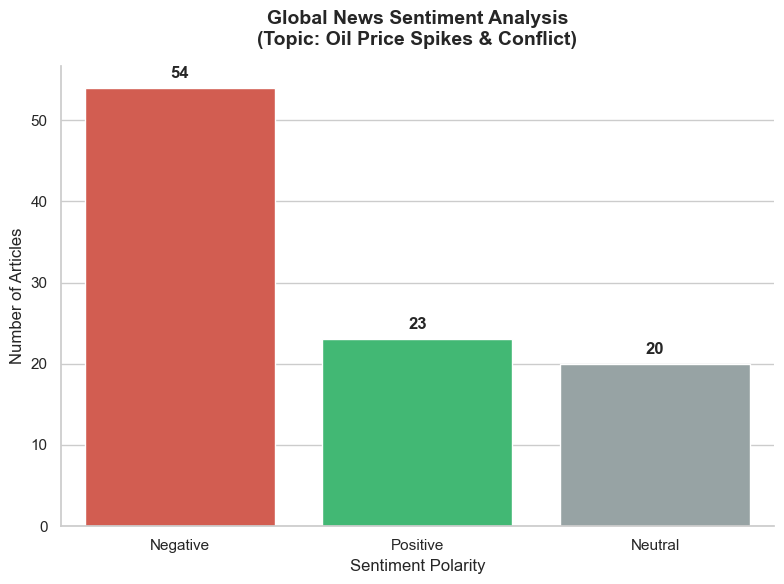

In [7]:
#Plot 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


data = {
    'Sentiment': ['Negative', 'Positive', 'Neutral'],
    'Article Count': [54, 23, 20]
}

sentiment_df = pd.DataFrame(data)


plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")


sentiment_colors = {'Negative': '#e74c3c', 'Positive': '#2ecc71', 'Neutral': '#95a5a6'}


ax = sns.barplot(
    x='Sentiment', 
    y='Article Count', 
    data=sentiment_df, 
    palette=sentiment_colors
)


plt.title("Global News Sentiment Analysis\n(Topic: Oil Price Spikes & Conflict)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sentiment Polarity", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)


for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), textcoords='offset points',
                fontsize=12, fontweight='bold')


sns.despine()
plt.tight_layout()
plt.show()